## load necessary libraries

In [176]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

## load datasets

In [177]:
# ========== Load and Prepare Data ==========
#source_profiles = pd.read_excel("Heavymetal_sources_git.xlsx")
source_profiles = pd.read_excel("Heavymetal_sources_git.xlsx")
#fog_samples = pd.read_excel("Fog_chemistry_data.xlsx", sheet_name="Sheet1")

fog_samples2 = pd.read_excel("IGP_test_bihar_git.xlsx")

In [178]:
# Set index
source_profiles = source_profiles.set_index("Element")
#fog_samples = fog_samples.set_index("Sample ID")

fog_samples2 = fog_samples2.set_index("Sample ID")

In [179]:
# Match common elements
common_elements = source_profiles.index.intersection(fog_samples2.columns)
#S = source_profiles.loc[common_elements].T  # shape: (sources, elements)
S = source_profiles.loc[common_elements]  # shape: (elements, sources)
#B = fog_samples[common_elements]            # shape: (samples, elements)

B2 = fog_samples2[common_elements]            # shape: (samples, elements)

In [180]:
S

,Coal,Fuel oil/Traffic,Crust,Industry average,Biomass/Wood burning
K,337000,0,2090,3.000000e+02,50280
Ca,2774000,139000,4150,6.500000e+03,40
Na,618300,1393750,2360,9.000000e+03,560
Mg,378600,9200,2330,3.136000e+05,20
Mn,19800,0,950000,4.212100e+05,2400
Cu,39500,0,55000,1.140000e+05,2200
As,39200,270,1800,1.000000e+03,200
Cd,0,2800,200,1.400000e+04,40
Pb,25000,2300,12500,1.020183e+07,1160


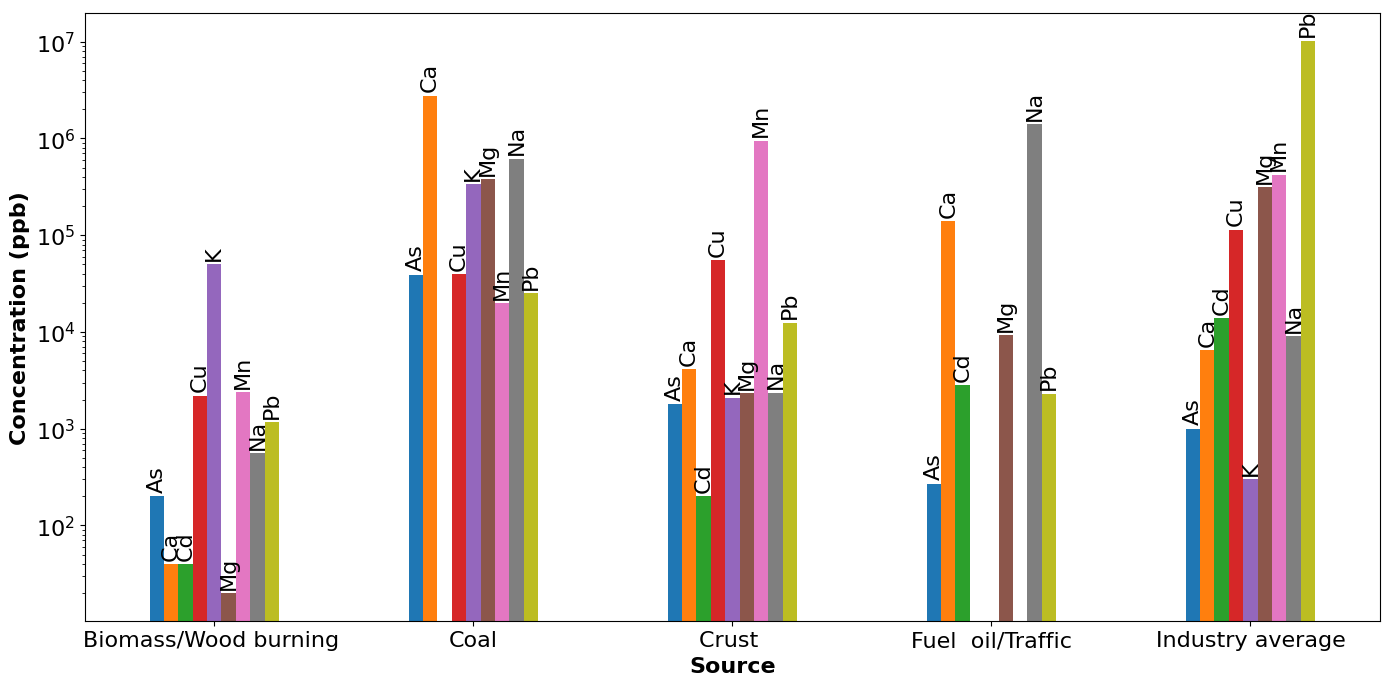

In [181]:
# Prepare for bar plotting
df_long = S.reset_index().melt(id_vars='index', var_name='Source', value_name='Concentration').rename(columns={'index': 'Element'})
pivot_df = df_long.pivot(index='Source', columns='Element', values='Concentration')

fig, ax = plt.subplots(figsize=(14, 7))
bars = pivot_df.plot(kind='bar', logy=True, ax=ax)

#plt.title('Element Concentrations by Source', fontsize=12)
plt.xlabel('Source', fontsize=16, fontweight='bold')
plt.ylabel('Concentration (ppb)', fontsize=16, fontweight='bold')
plt.xticks(rotation=360, fontsize=16)
plt.yticks(fontsize=16)

# Annotate element names above each bar
for container, element in zip(ax.containers, pivot_df.columns):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{element}',
                (bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=16,
                rotation=90,
                color='black'
            )

# Hide legend
ax.legend_.remove()
plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/New_data/source_data_xmarine.png",bbox_inches = 'tight', dpi = 600)
plt.show()

In [182]:
# normalize source dataset
def normalize_rows_df(df: pd.DataFrame) -> pd.DataFrame:
    # Sum per row
    row_sums = df.sum(axis=1)
    row_sums[row_sums == 0] = 1
    df_normalized = df.div(row_sums, axis=0)
    return df_normalized# Example with Pandas DataFrame

In [183]:
S_norm = normalize_rows_df(S)

In [184]:
S_norm

,Coal,Fuel oil/Traffic,Crust,Industry average,Biomass/Wood burning
K,0.864834,0.000000,0.005364,0.000770,0.129032
Ca,0.948801,0.047543,0.001419,0.002223,0.000014
Na,0.305489,0.688622,0.001166,0.004447,0.000277
Mg,0.537975,0.013073,0.003311,0.445613,0.000028
Mn,0.014210,0.000000,0.681781,0.302287,0.001722
Cu,0.187470,0.000000,0.261035,0.541054,0.010441
As,0.923004,0.006357,0.042383,0.023546,0.004709
Cd,0.000000,0.164319,0.011737,0.821596,0.002347
Pb,0.002441,0.000225,0.001220,0.996001,0.000113


In [185]:
B2

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
Sample ID,,,,,,,,,
A01,2310,8969.0,3934.0,917,30.308341,2.784601,0.603964,0.174142,0.222554
A02,5502,17898.0,1928.0,1888,36.167207,2.660512,1.737325,0.040476,0.065047
A03,655,3094.0,1016.0,429,2.175061,0.196934,0.221245,0.023078,0.264469
A04,994,6383.0,1319.0,570,12.125012,0.386724,0.450641,0.065521,0.216171
A05,4609,12990.0,1319.0,1046,21.627446,3.690045,1.966823,0.520398,1.880526
A06,2497,15062.0,1796.0,1325,6.369622,2.299650,0.910618,0.089380,0.842433
A07,2197,6110.0,1252.0,694,13.247568,0.435061,0.518654,0.076857,0.436541
A08,834,2774.0,523.0,281,8.913263,0.911796,0.732502,0.339337,2.209108
A09,2613,7878.0,815.0,771,63.106824,3.384211,3.267257,0.819575,3.122012


<Figure size 800x350 with 0 Axes>

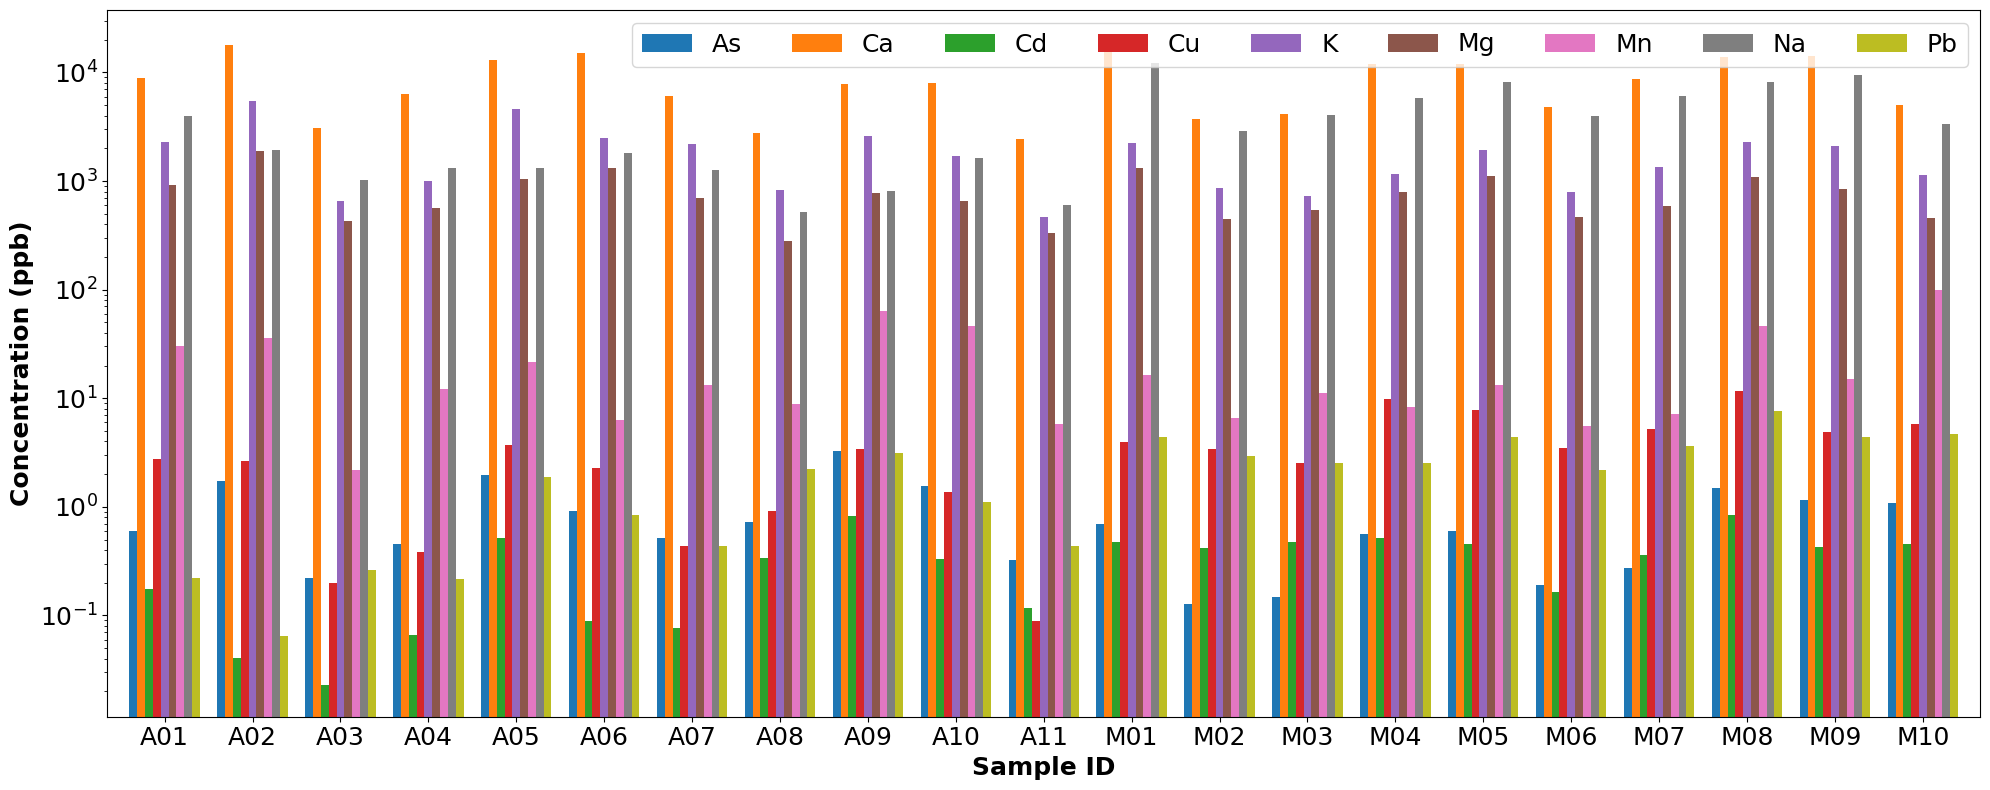

In [186]:
sample = [
    'M01','M02','M03','M04','M05','M06','M07','M08','M09','M10','A01','A02','A03','A04','A05','A06','A07','A08','A09','A10','A11'
]
B1 = pd.DataFrame(B2, index=sample)

# Melt to long form for plotting
B_long = B1.reset_index().melt(
    id_vars='index',
    var_name='Element',
    value_name='Concentration'
).rename(columns={'index': 'Sample ID'})

# Create bar plot: one bar per element per date
plt.figure(figsize=(8,3.5))
bar_df = B_long.set_index(['Sample ID', 'Element'])['Concentration']
bar_df.unstack('Element').plot.bar(
    logy=True,
    width=0.8,
    figsize=(20,8)
)

#plt.title('Element Concentrations over Time')
plt.xlabel('Sample ID', fontsize=18,fontweight='bold')
plt.ylabel('Concentration (ppb)', fontsize=18,fontweight='bold')
plt.xticks(rotation=0, fontsize=18)
plt.yticks(fontsize=18)
plt.legend(ncol=9, fontsize=18)
plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/New_data/sample_data1.png",bbox_inches = 'tight', dpi = 300)
plt.show()

## data augmentation

In [187]:
# Function to add noise
def augment_unsupervised_data(df, n_augments=10, noise_level=0.05):
    synthetic_data = []
    
    for _ in range(n_augments):
        noisy_df = df + np.random.normal(loc=0.0, scale=noise_level, size=df.shape)
        noisy_df = pd.DataFrame(noisy_df, columns=df.columns)
        synthetic_data.append(noisy_df)

    df_aug = pd.concat(synthetic_data + [df], ignore_index=True)
    return df_aug

# Generate 10 noisy versions → final dataset: 11 × (1+10) = 121 rows
B_augmented = augment_unsupervised_data(B2, n_augments=10, noise_level=0.05)

In [188]:
B_augmented

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
0,2309.989651,8969.035669,3934.017842,916.998221,30.295392,2.713823,0.616153,0.173794,0.260388
1,5501.914514,17898.051859,1928.011078,1887.982003,36.161031,2.605359,1.706908,-0.041407,0.066890
2,654.992855,3094.053768,1015.946685,429.012624,2.292875,0.192578,0.205040,-0.065300,0.291178
3,994.015871,6382.960395,1318.987109,569.997300,12.102412,0.395263,0.441322,0.059771,0.304331
4,4608.969566,12990.071198,1319.008240,1046.017780,21.670566,3.679574,1.964248,0.424702,1.925495
...,...,...,...,...,...,...,...,...,...
226,799.000000,4850.000000,3933.000000,467.000000,5.608000,3.493000,0.190000,0.164000,2.181000
227,1347.000000,8778.000000,6093.000000,590.000000,7.110000,5.258000,0.271000,0.362000,3.670000
228,2305.000000,13991.000000,8198.000000,1083.000000,46.363000,11.716000,1.487000,0.840000,7.665000
229,2092.000000,14023.000000,9388.000000,847.000000,15.072000,4.875000,1.161000,0.428000,4.440000


In [189]:
B2.shape[1]

9

In [190]:
# ---- 2. Statistical Comparison ----
def compare_statistics(df1, df2):
    stat_df = pd.DataFrame({
        'mean_original': df1.mean(),
        'mean_augmented': df2.mean(),
        'std_original': df1.std(),
        'std_augmented': df2.std(),
        'corr': [df1[col].corr(df2[col]) for col in df1.columns]
    })
    print("Statistical Comparison:\n", stat_df)
    return stat_df

In [191]:
stat_df = compare_statistics(B2, B_augmented)

Statistical Comparison:
     mean_original  mean_augmented  std_original  std_augmented  corr
K     1856.142857     1856.140358   1273.851023    1245.848527   NaN
Ca    9007.095238     9007.099150   5088.861561    4977.003523   NaN
Na    3825.000000     3824.998405   3320.966922    3247.969610   NaN
Mg     789.714286      789.710577    397.838679     389.095194   NaN
Mn      22.625184       22.624260     24.009083      23.484960   NaN
Cu       3.660462        3.661953      3.108364       3.039841   NaN
As       0.885375        0.883881      0.770100       0.760718   NaN
Cd       0.342480        0.339907      0.237648       0.240001   NaN
Pb       2.392415        2.395151      1.990119       1.945371   NaN


In [192]:
# ---- 5. Visualization ----
def plot_feature_trends(df1, df2, num_features=9):
    for col in df1.columns[:num_features]:
        plt.figure(figsize=(8, 4))
        plt.plot(df1[col].values, label='Original', marker='o')
        plt.plot(df2[col].values[:len(df1)], label='Augmented (first 11)', linestyle='--')
        plt.title(f"Trend Comparison: {col}")
        plt.legend()
        plt.grid(True)
        plt.show()

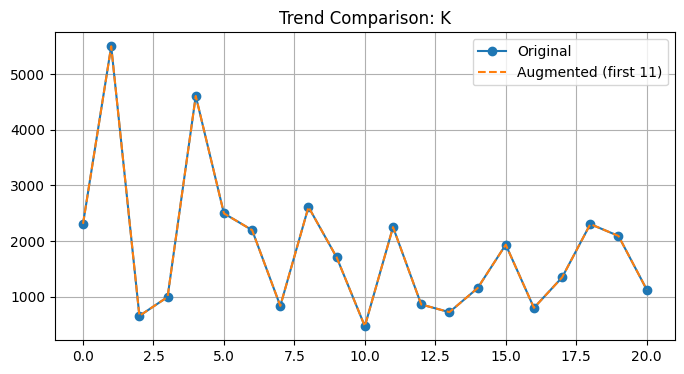

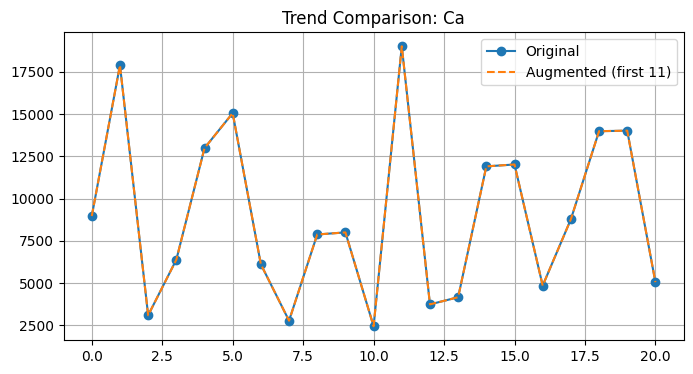

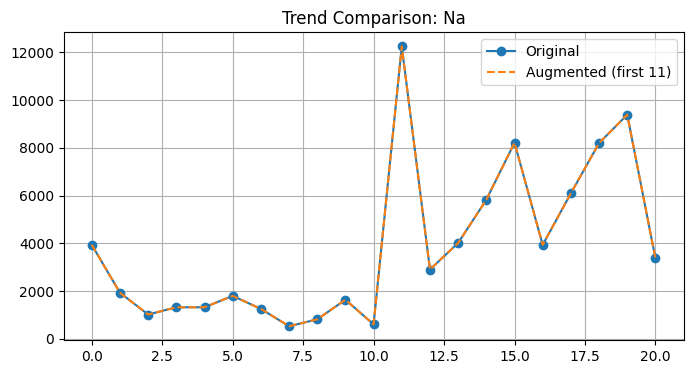

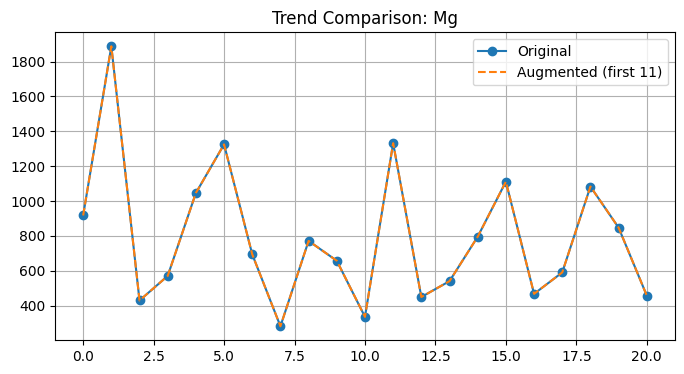

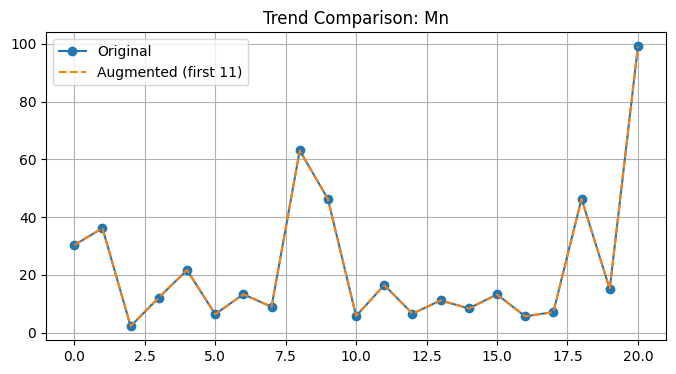

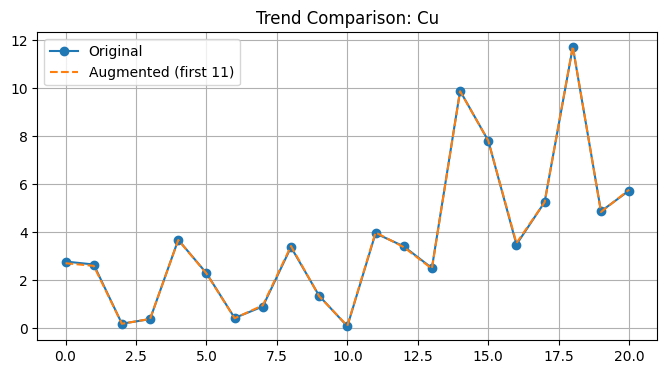

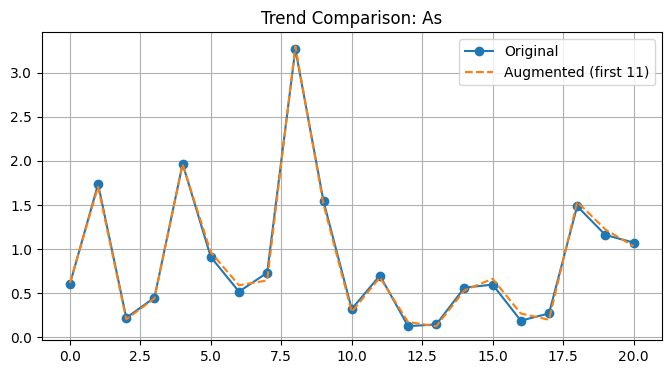

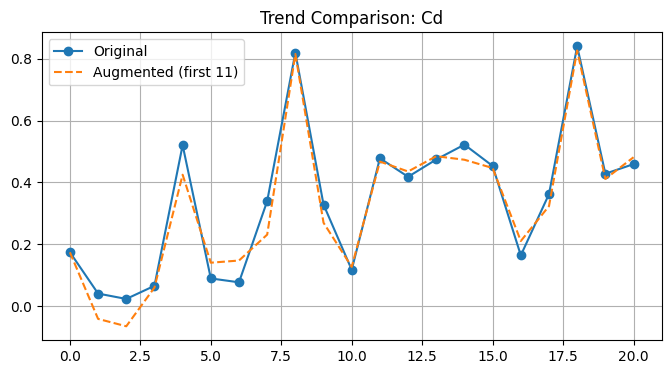

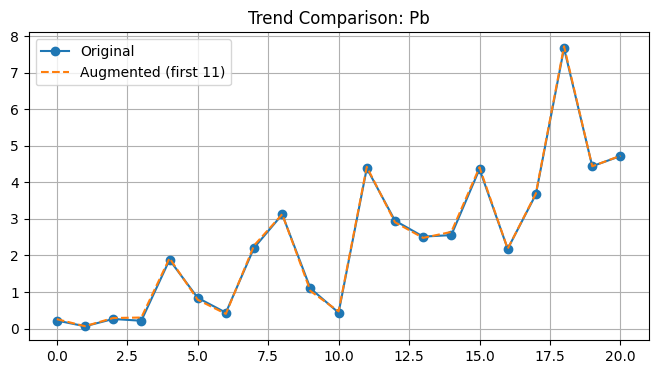

In [193]:
plot_feature_trends(B2, B_augmented)

In [194]:
ones1 = np.ones(5, dtype = None, order = 'F')

In [195]:
ones1

array([1., 1., 1., 1., 1.])

In [196]:
S_matrix = np.vstack([S_norm,ones1])

In [197]:
S_matrix

array([[8.64834347e-01, 0.00000000e+00, 5.36351272e-03, 7.69882208e-04,
        1.29032258e-01],
       [9.48801001e-01, 4.75426601e-02, 1.41943913e-03, 2.22321792e-03,
        1.36813410e-05],
       [3.05488718e-01, 6.88621867e-01, 1.16602519e-03, 4.44670623e-03,
        2.76683943e-04],
       [5.37975133e-01, 1.30728242e-02, 3.31083481e-03, 4.45612789e-01,
        2.84191829e-05],
       [1.42097444e-02, 0.00000000e+00, 6.81780668e-01, 3.02287195e-01,
        1.72239327e-03],
       [1.87470337e-01, 0.00000000e+00, 2.61034646e-01, 5.41053631e-01,
        1.04413859e-02],
       [9.23004474e-01, 6.35742877e-03, 4.23828585e-02, 2.35460325e-02,
        4.70920650e-03],
       [0.00000000e+00, 1.64319249e-01, 1.17370892e-02, 8.21596244e-01,
        2.34741784e-03],
       [2.44074045e-03, 2.24548121e-04, 1.22037022e-03, 9.96001091e-01,
        1.13250357e-04],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00]])

## Normalisation of sample data

In [198]:
from sklearn.preprocessing import MinMaxScaler
scaler_x=MinMaxScaler(feature_range=(0, 1)).fit(B_augmented)

In [199]:
B_scaled = scaler_x.transform(B_augmented)

In [200]:
#B_scaled = B_scaled.T

In [201]:
# Create a column of ones with same number of rows
ones = np.ones((B_scaled.shape[0], 1))

# Add the ones column to A
B_matrix = np.hstack((B_scaled, ones))


In [202]:
B_matrix.shape

(231, 10)

In [203]:
S_matrix.shape

(10, 5)

In [204]:
# Prepare data
B_input = B_matrix[:185]                          # (samples × elements)
B_test = B_matrix[185:]
#Y_target = np.linalg.pinv(S_matrix) @ X_input  # (samples × sources)

In [205]:
#Define objective functions

def objective(x):
    return np.linalg.norm(S_matrix @ x - b)**2

In [206]:
bounds = [(1e-6, None)] * S_matrix.shape[1]  # Enforce x_i > 0

In [207]:
x0 = np.ones(S_matrix.shape[1])  # Initial guess (1 for each source)

In [208]:
from scipy.optimize import minimize

In [209]:
X = []
for b in B_input:
    result = minimize(objective, x0=np.ones(S_matrix.shape[1]), bounds=bounds)
    X.append(result.x)

X = np.array(X)  # shape (samples x sources)

In [210]:
Y_target = X

In [211]:
Y_target

array([[3.53228803e-01, 2.39032800e-01, 2.90685071e-01, 1.44147575e-01,
        1.00000000e-06],
       [9.12399999e-01, 1.00000000e-06, 1.31170821e-01, 8.70479677e-02,
        1.00000000e-06],
       [2.37059862e-02, 6.54053228e-02, 4.50342860e-03, 3.35908608e-02,
        8.60491964e-01],
       [1.52251044e-01, 8.39663620e-02, 1.00737561e-01, 7.91881834e-02,
        5.70074563e-01],
       [6.89006695e-01, 1.00000000e-06, 1.09708486e-02, 3.51146860e-01,
        1.00000000e-06],
       [5.71376866e-01, 1.00000000e-06, 1.00000000e-06, 2.16316067e-01,
        1.95774875e-01],
       [2.41278002e-01, 4.67996063e-03, 3.89632578e-02, 1.25388893e-01,
        5.96208288e-01],
       [3.33422797e-02, 1.73317893e-02, 1.00000000e-06, 2.61346192e-01,
        6.82363512e-01],
       [4.80240215e-01, 1.00000000e-06, 2.14373222e-01, 5.14172268e-01,
        1.00000000e-06],
       [3.40009520e-01, 2.06073260e-02, 4.70500761e-01, 1.80948897e-01,
        1.00000000e-06],
       [1.00000000e-06, 6.7549

In [212]:
# Assuming y_train is a NumPy array of shape (97, 6)
Y_target_df = pd.DataFrame(Y_target, columns=[f'Target_{i}' for i in range(Y_target.shape[1])])

In [213]:
#Y_target_log

In [214]:
#y_train_transformed_df = pd.DataFrame(y_transformed, columns=[f'Target_{i}' for i in range(y_train_transformed.shape[1])])

## Model building

In [215]:
# ========== Train Random Forest ==========
rf_model = RandomForestRegressor(n_estimators=1000,criterion='absolute_error')#, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, n_jobs=-1, random_state=42, verbose=0, max_samples=None)

# Wrap for multi-output
multi_rf = MultiOutputRegressor(rf_model)
multi_rf.fit(B_input, Y_target)   # Multi-output regression

MultiOutputRegressor(estimator=RandomForestRegressor(criterion='absolute_error',
                                                     n_estimators=1000))

In [216]:
# ========== Predict B ==========
X_pred = multi_rf.predict(B_test)  # shape: (samples × sources)

In [217]:
X_pred.shape

(46, 5)

In [218]:
import numpy as np
# Sum of source apportionments

print(np.sum(X_pred[25:], axis=1))

[1.03295601 1.13366016 0.99949469 0.98520429 1.06956321 0.99192212
 0.99805445 0.9949651  1.20886688 1.01783493 0.9910847  1.39198682
 1.00997677 1.00706194 1.13167814 1.22870105 0.99945733 1.06912082
 1.38589037 1.25129298 1.26982241]


In [219]:
X_pred1=X_pred[25:]

## Estimated Source apportionment

In [220]:
# ========== Save B Matrix ==========
contributions_df = pd.DataFrame(X_pred1, columns=S.columns)
#contributions_df.to_excel("D:/IIITK_final/IIITK/Fog_SKD/New_data/random_for_bihar.xlsx")
print("Estimated Source Contributions (X):")
print(contributions_df.round(4))

Estimated Source Contributions (X):
      Coal  Fuel  oil/Traffic  Crust   Industry average  Biomass/Wood burning 
0   0.3552             0.2372  0.2956            0.1450                 0.0000
1   0.9112             0.0000  0.1092            0.1133                 0.0000
2   0.0238             0.0826  0.0034            0.0627                 0.8271
3   0.1522             0.0867  0.0990            0.0817                 0.5657
4   0.6818             0.0000  0.0021            0.3857                 0.0000
5   0.5685             0.0000  0.0001            0.2031                 0.2202
6   0.2348             0.0019  0.0481            0.1021                 0.6111
7   0.0360             0.0439  0.0000            0.2966                 0.6185
8   0.4789             0.0000  0.2166            0.5134                 0.0000
9   0.3396             0.0219  0.4491            0.2073                 0.0000
10  0.0000             0.0609  0.0214            0.0994                 0.8093
11  0.5119      

In [221]:
X_pred1.shape[0]

21

In [222]:
# ========== Reconstruct B ==========
B_hat = []
for i in range(X_pred1.shape[0]):
    B_hat_i = S_matrix @ X_pred1[i]
    B_hat.append(B_hat_i)
    
#B_hat = X_pred @ S_matrix
#B_hat_df = pd.DataFrame(B_hat)

In [223]:
B_hat = np.array(B_hat)

In [224]:
# ========== Evaluate Reconstruction (MSE) ==========
mses = []
for i in range(B_test[25:].shape[0]):
    mse = mean_squared_error(B_test[25:][i], B_hat[i])
    mses.append(mse)
    print(f"\nReconstruction MSE: {mse:.4f}")
np.average(mses)


Reconstruction MSE: 0.0074

Reconstruction MSE: 0.0478

Reconstruction MSE: 0.0015

Reconstruction MSE: 0.0034

Reconstruction MSE: 0.0180

Reconstruction MSE: 0.0210

Reconstruction MSE: 0.0030

Reconstruction MSE: 0.0087

Reconstruction MSE: 0.0703

Reconstruction MSE: 0.0105

Reconstruction MSE: 0.0032

Reconstruction MSE: 0.0823

Reconstruction MSE: 0.0030

Reconstruction MSE: 0.0028

Reconstruction MSE: 0.0454

Reconstruction MSE: 0.0332

Reconstruction MSE: 0.0031

Reconstruction MSE: 0.0113

Reconstruction MSE: 0.0718

Reconstruction MSE: 0.0308

Reconstruction MSE: 0.0359


0.024498038262177484

In [225]:
# ========== Evaluate Reconstruction (RMSE) ==========
rmses = []
for i in range(B_test[25:].shape[0]):
    rmse = root_mean_squared_error(B_test[25:][i], B_hat[i])
    rmses.append(rmse)
    print(f"\nReconstruction RMSE: {rmse:.4f}")
np.average(rmses)


Reconstruction RMSE: 0.0862

Reconstruction RMSE: 0.2186

Reconstruction RMSE: 0.0389

Reconstruction RMSE: 0.0579

Reconstruction RMSE: 0.1342

Reconstruction RMSE: 0.1449

Reconstruction RMSE: 0.0545

Reconstruction RMSE: 0.0935

Reconstruction RMSE: 0.2651

Reconstruction RMSE: 0.1026

Reconstruction RMSE: 0.0569

Reconstruction RMSE: 0.2870

Reconstruction RMSE: 0.0550

Reconstruction RMSE: 0.0526

Reconstruction RMSE: 0.2130

Reconstruction RMSE: 0.1823

Reconstruction RMSE: 0.0561

Reconstruction RMSE: 0.1061

Reconstruction RMSE: 0.2679

Reconstruction RMSE: 0.1756

Reconstruction RMSE: 0.1894


0.13515884098760764

In [226]:
# ========== Evaluate Reconstruction (MAE)==========
maes = []
for i in range(B_test[25:].shape[0]):
    mae = mean_absolute_error(B_test[25:][i], B_hat[i])
    maes.append(mae)
    print(f"\nReconstruction MAE: {mae:.4f}")
np.average(maes)


Reconstruction MAE: 0.0703

Reconstruction MAE: 0.1741

Reconstruction MAE: 0.0311

Reconstruction MAE: 0.0498

Reconstruction MAE: 0.1070

Reconstruction MAE: 0.1086

Reconstruction MAE: 0.0459

Reconstruction MAE: 0.0700

Reconstruction MAE: 0.2176

Reconstruction MAE: 0.0799

Reconstruction MAE: 0.0445

Reconstruction MAE: 0.2315

Reconstruction MAE: 0.0442

Reconstruction MAE: 0.0374

Reconstruction MAE: 0.1753

Reconstruction MAE: 0.1430

Reconstruction MAE: 0.0434

Reconstruction MAE: 0.0889

Reconstruction MAE: 0.2119

Reconstruction MAE: 0.1391

Reconstruction MAE: 0.1597


0.10825989436279103

In [227]:
B_hat.shape

(21, 10)

In [228]:
B_trimmed = B_hat[:, :-1]

In [229]:
B_trimmed.shape

(21, 9)

In [230]:
# To compare with real B,inverse transform is required:
B_inv_df = scaler_x.inverse_transform(B_trimmed)

In [231]:
B_hat_df = pd.DataFrame(B_inv_df, columns=B_augmented.columns)
B_hat_df

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
0,2022.841554,8228.713874,3723.735894,698.407533,26.472476,2.598955,1.163893,0.098636,1.130358
1,4438.180695,16779.077092,3795.664601,1150.466894,13.961858,3.053969,2.843256,0.030492,0.894861
2,1108.913421,2885.112812,1281.254319,348.126981,4.378965,0.536306,0.104437,0.002718,0.487284
3,1500.857924,4910.532777,1775.766848,473.339095,11.403044,1.205785,0.511144,0.019751,0.636830
4,3437.643304,13179.279891,2986.325466,1146.622202,14.552100,3.958167,2.142620,0.256286,2.988958
5,3086.889685,11391.747735,2571.654138,917.947413,8.936599,2.558934,1.782474,0.104563,1.579564
6,1888.868811,6143.083416,1387.803731,557.388490,8.757565,1.368575,0.759177,0.022160,0.795333
7,1027.392479,3055.144820,1024.105814,525.361551,11.007010,2.024759,0.155872,0.190742,2.290248
8,2560.553276,9998.270194,2268.767304,1063.769050,32.233948,4.988152,1.557746,0.365283,3.971293
9,1959.188112,7819.179404,1933.534131,725.797642,38.452690,3.437400,1.137787,0.116491,1.611277


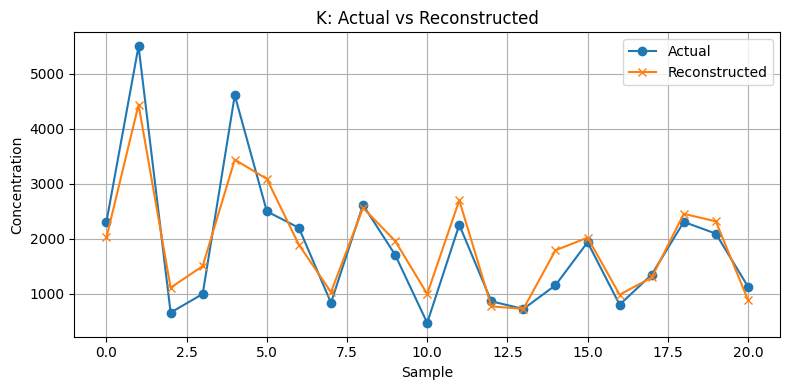

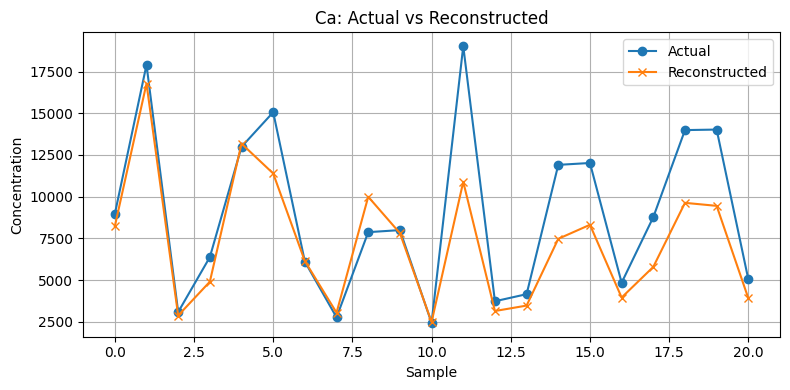

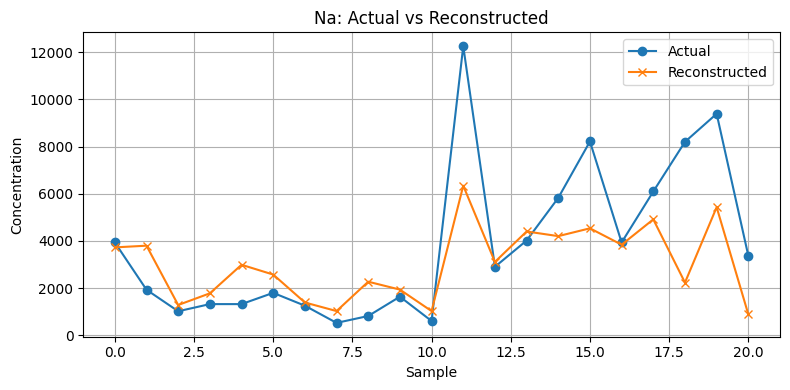

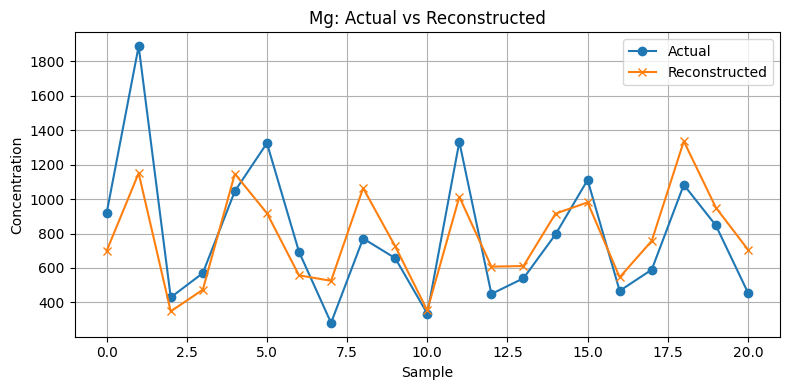

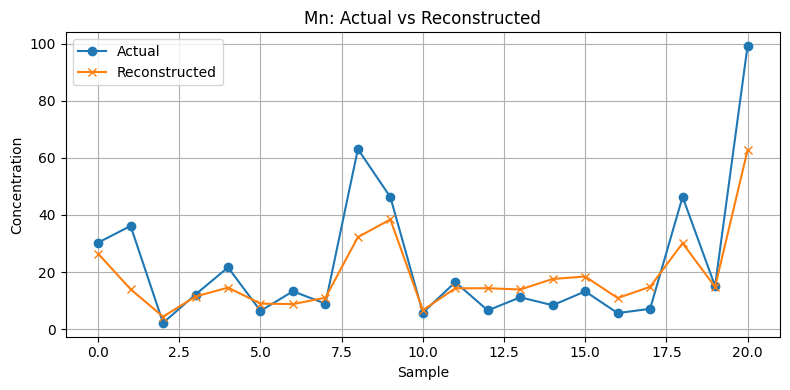

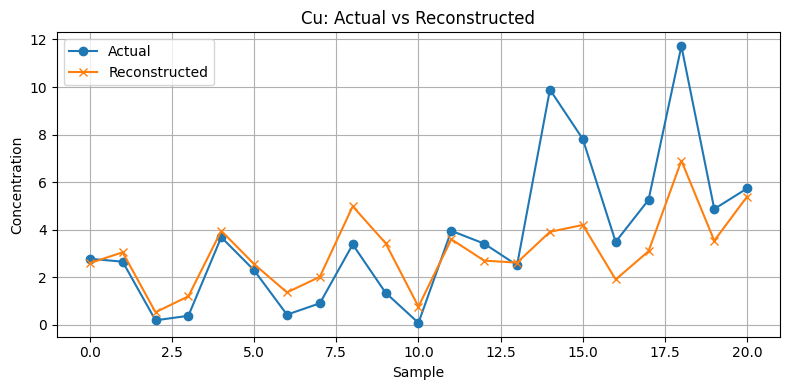

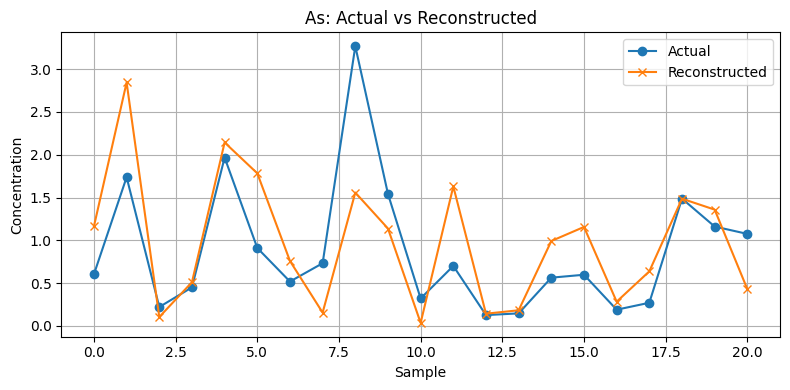

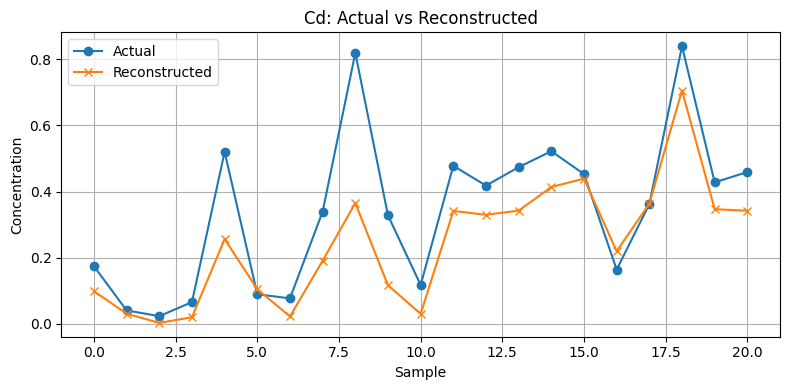

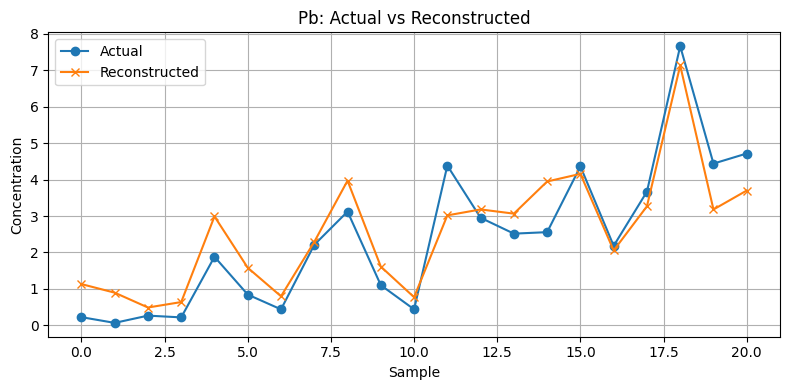

In [232]:
# ========== Optional: Plot Actual vs Reconstructed ==========
for element in B_augmented.columns[:9]:  # First 3 elements
    plt.figure(figsize=(8, 4))
    plt.plot(B_augmented[210:][element].values, label='Actual', marker='o')
    plt.plot(B_hat_df[element].values, label='Reconstructed', marker='x')
    plt.title(f'{element}: Actual vs Reconstructed')
    plt.xlabel("Sample")
    plt.ylabel("Concentration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

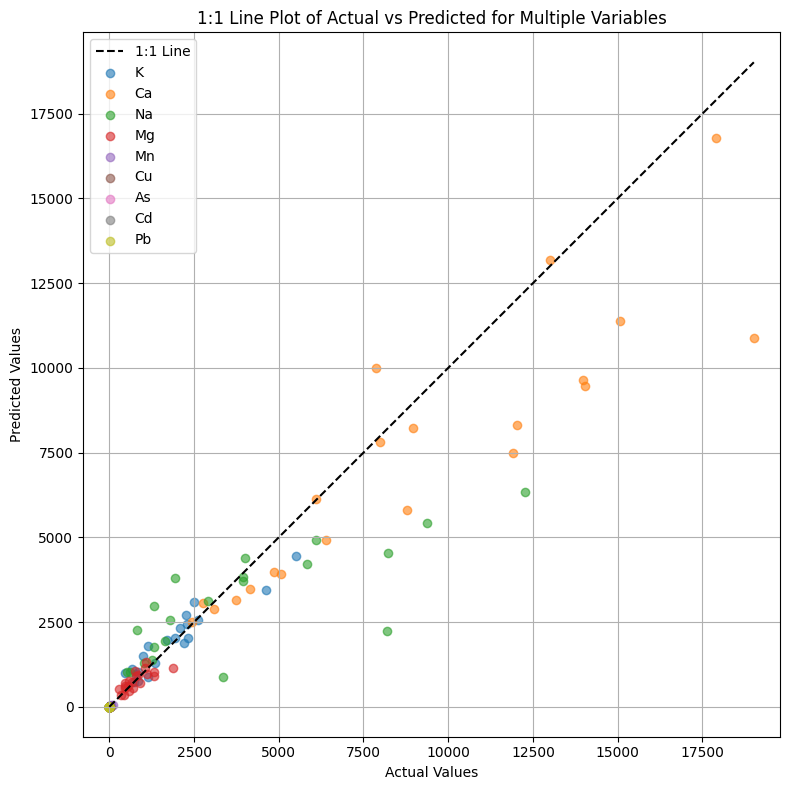

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Plot
plt.figure(figsize=(8, 8))
min_val = min(B_augmented[210:].min().min(),B_hat_df.min().min())
max_val = max(B_augmented[210:].max().max(), B_hat_df.max().max())

# 1:1 line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Scatter plot for each variable
for col in B_augmented.columns:
    plt.scatter(B_augmented[210:][col], B_hat_df[col], label=col, alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("1:1 Line Plot of Actual vs Predicted for Multiple Variables")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/New_data/result_all_rf_opt_bihar.png",bbox_inches = 'tight', dpi = 600)
plt.show()

In [234]:
b_aug = np.asarray(B_augmented[210:])

In [235]:
b_aug = b_aug.flatten()

In [236]:
b_pred = np.asarray(B_hat_df)

In [237]:
b_pred = b_pred.flatten()

In [238]:
from sklearn.metrics import r2_score

r2 = []
for col in B2.columns:
    r2_sc=r2_score(B_augmented[210:][col], B_hat_df[col])
    r2.append(r2_sc)


print("R2 score:", r2)

R2 score: [0.8564550502842723, 0.6658235496575242, 0.4557332326833574, 0.5932883381304659, 0.6981698344411824, 0.5228529998217211, 0.3374551682659641, 0.5934652671497449, 0.8482491576510856]


In [239]:
r2_all=r2_score(b_aug,b_pred)

In [240]:
r2_all

0.8704919215548909

In [241]:
np.average(r2)

0.6190547331205908

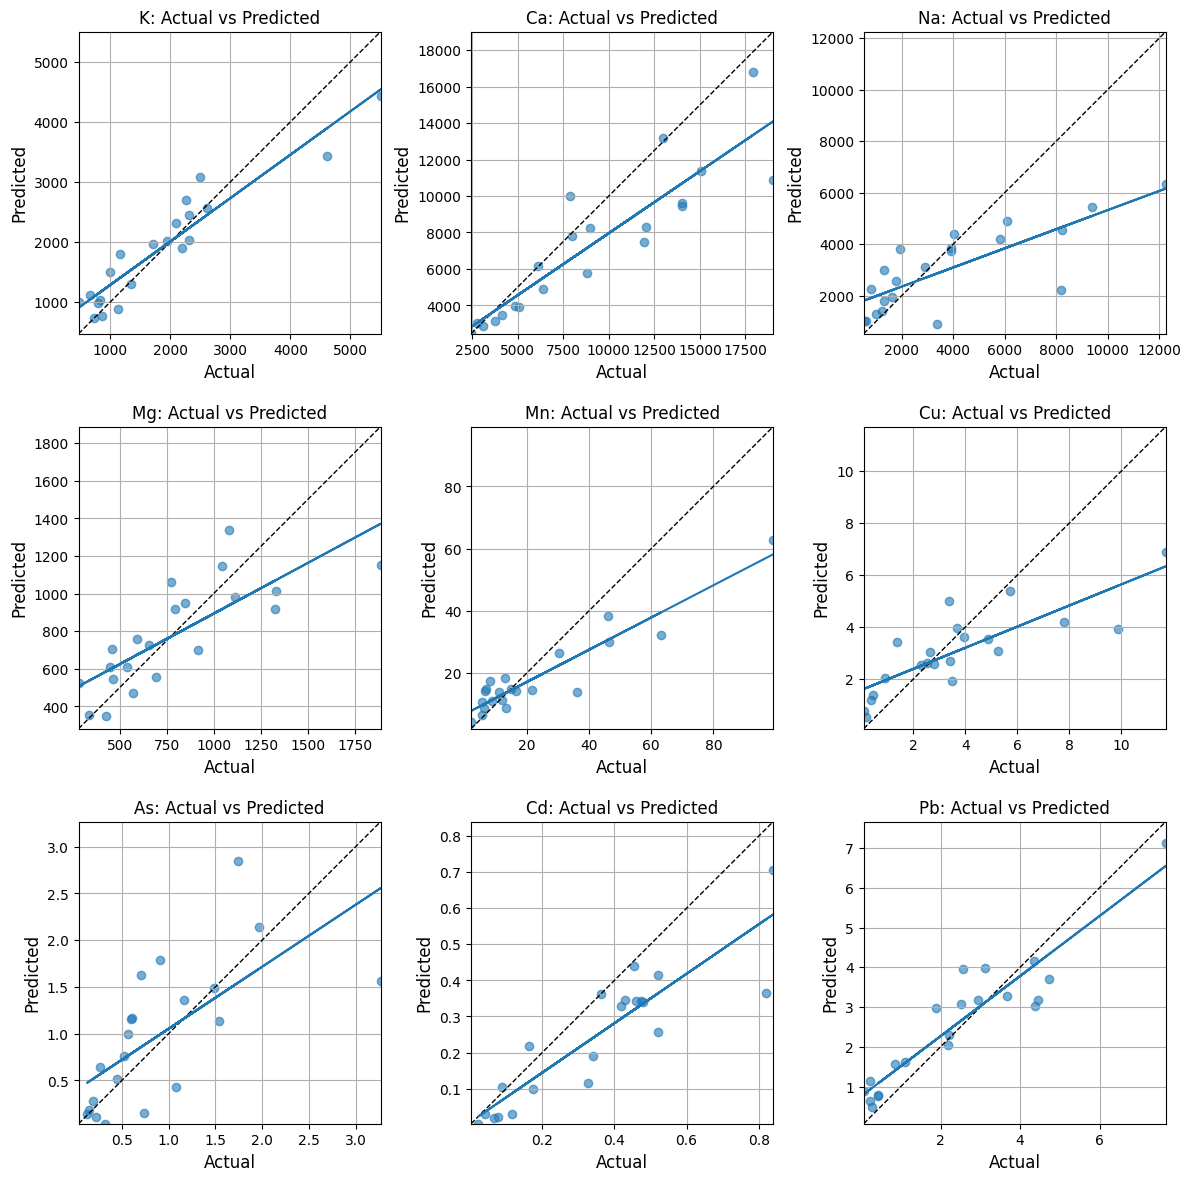

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Example data (replace with your actual data)
#columns = ['var1', 'var2', 'var3', 'var4', 'var5']

# Grid size
n_vars = len(B_augmented.columns)
n_cols = 3  # number of plots per row
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

# Flatten axes array for easy indexing
axes = axes.flatten()

for i, col in enumerate(B_augmented.columns):
    ax = axes[i]
    
    # Limits
    min_val = min(B_augmented[210:][col].min(), B_hat_df[col].min())#-25
    max_val = max(B_augmented[210:][col].max(), B_hat_df[col].max())#+25
    
    # 1:1 reference line
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    # Scatter actual vs predicted
    ax.scatter(B_augmented[210:][col], B_hat_df[col], alpha=0.6)

    #for uncertainty plot
    m,c = np.polyfit(B_augmented[210:][col].values, B_hat_df[col].values, 1)
    mx = m*B2[col].values
    ax.plot(B2[col].values, mx+c)
    
    
    #ax.annotate(fontsize=14, color='black')
    ax.set_title(f'{col}: Actual vs Predicted', fontsize = 12)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True)
    ax.set_aspect('equal')

# Hide unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/New_data/result_ind_rf_opt_bihar.png",bbox_inches = 'tight', dpi = 600)
plt.show()

In [243]:
# Calculating intercept and coefficient

for i, col in enumerate(B2.columns):
    #print(X[col].values)
    m,c = np.polyfit(B_augmented[210:][col].values, B_hat_df[col].values, 1).round(2)
    mx = m*(B_augmented[210:][col].values)
    print(B_augmented.columns[i])
    print("Y=",m,"X+",c)

K
Y= 0.72 X+ 560.78
Ca
Y= 0.68 X+ 1154.74
Na
Y= 0.37 X+ 1610.16
Mg
Y= 0.54 X+ 355.19
Mn
Y= 0.52 X+ 6.78
Cu
Y= 0.41 X+ 1.58
As
Y= 0.66 X+ 0.39
Cd
Y= 0.69 X+ 0.01
Pb
Y= 0.76 X+ 0.76
